In [ ]:
import sys,os
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report

from scripts.path_configs import *


In [ ]:
__script_path=os.path.abspath(globals().get('__file__','.'))
__script_dir = os.path.dirname(__script_path)
root_dir = os.path.abspath(f'{__script_dir}/../../..')
print(root_dir)
for lib in [root_dir][::-1]:
    if lib in sys.path:
        sys.path.remove(lib)
    sys.path.insert(0,lib)

In [ ]:
# Import Dataset
df=pd.read_csv('/content/loan_data.csv')

tar_column='loan_status'
Num_col=df.select_dtypes('number').columns.tolist()[:-1]
Cat_col=df.select_dtypes('object').columns.tolist()

x_train=pd.read_csv(f"{exps_dir}/x_train.csv", index_col=None)
x_test=pd.read_csv(f"{exps_dir}/x_test.csv", index_col=None)
y_train=pd.read_csv(f"{exps_dir}/y_train.csv", index_col=None)
y_test=pd.read_csv(f"{exps_dir}/y_test.csv", index_col=None)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


# **4. Modeling ML**

## **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model_li = LogisticRegression()

In [ ]:
model_li.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred_li = model_li.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred_li))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(max_depth=10)

In [ ]:
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      6990
           1       0.85      0.74      0.79      2010

    accuracy                           0.91      9000
   macro avg       0.89      0.85      0.87      9000
weighted avg       0.91      0.91      0.91      9000



## **Grid Search Hyper Para**

In [ ]:
!pip show xgboost

Name: xgboost
Version: 2.1.4
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: 


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [ ]:
param_grid = {
    'n_estimators': [100, 140, 200, 250],
    'max_depth': [5, 8, 12, 16],
    'min_samples_split': [2, 5, 10, 20, 24],
    'max_features': ['sqrt', 'log2', 'auto']
}

In [ ]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=50),
    param_grid=param_grid,
    cv=5,
    scoring='f1',  # Tối ưu theo F1-score
    n_jobs=-1  # Chạy song song để tiết kiệm thời gian
)

In [ ]:
# Train
grid_search.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:22:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "max_features", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=50, ...),
             n_jobs=-1,
             param_grid={'max_depth': [5, 8, 12, 16],
                         'max_features': ['sqrt', 'log2', 'auto'],
                         'min_samples_split': [2, 5, 10, 20, 24],
                         'n_estimators': [100, 140, 200, 250]},
             scoring='f1')

In [ ]:
# Lấy Model được train với best para
best_model = grid_search.best_estimator_

In [ ]:
# Precdict
y_pred_rf_grid=best_model.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred_rf_grid))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6990
           1       0.88      0.81      0.84      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.89      0.90      9000
weighted avg       0.93      0.93      0.93      9000



# **5. Deep Learning Method**

## **Pytorch**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

### **Pytorch Architecture**

In [ ]:
class pytorchnn(nn.Module):
    def __init__(self, input_size, output_size, dropout_rate):
        super(pytorchnn, self).__init__()
        self.fc1 = nn.Linear(input_size, 180)
        self.bn1 = nn.BatchNorm1d(180)  
        self.fc2 = nn.Linear(180, 100)
        self.bn2 = nn.BatchNorm1d(100)
        self.fc3 = nn.Linear(100, 40)
        self.bn3 = nn.BatchNorm1d(40)
        self.fc4 = nn.Linear(40, 8)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc5 = nn.Linear(8, output_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.activation = nn.LeakyReLU(0.1)  

    def forward(self, x):
        out = self.activation(self.bn1(self.fc1(x)))
        out = self.dropout(out)
        out = self.activation(self.bn2(self.fc2(out)))
        out = self.dropout(out)
        out = self.activation(self.bn3(self.fc3(out)))
        out = self.fc4(out)
        out = self.dropout(out)
        out = self.fc5(out)
        return out

### **Setup Hyper Parameter**

In [ ]:
input_size= 13
output_size=1
dropout_rate=0.6

### **Khởi tạo DataLoader**

In [ ]:
train_data, test_data = train_test_split(df_ss, test_size=0.1, random_state=42)

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(train_data.drop(columns=tar_column,axis=1), train_data[tar_column], test_size=0.2, random_state=42)

In [ ]:
x_test, y_test = test_data.drop(columns=tar_column,axis=1), test_data[tar_column]

In [ ]:
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [ ]:
# khởi tạo Dataloader
train_loader = torch.utils.data.DataLoader(
    list(zip(x_train_tensor, y_train_tensor)), batch_size=70, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    list(zip(x_val_tensor, y_val_tensor)), batch_size=70, shuffle=False)
test_loader = torch.utils.data.DataLoader(
    list(zip(x_test_tensor, y_test_tensor)), batch_size=70, shuffle=False)

### **Khởi tạo Model**

In [ ]:

model_py = pytorchnn(input_size, output_size, dropout_rate)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_py.parameters(), lr=0.005, weight_decay=1e-5)

# scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                            factor=0.7,
                                                            patience=10,
                                                            min_lr=1e-6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_py.to(device)

pytorchnn(
  (fc1): Linear(in_features=13, out_features=180, bias=True)
  (bn1): BatchNorm1d(180, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=180, out_features=100, bias=True)
  (bn2): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=100, out_features=40, bias=True)
  (bn3): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=40, out_features=8, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
  (activation): LeakyReLU(negative_slope=0.1)
)

### **Train Model**

In [ ]:
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
num_epoch = 500

for epoch in range(num_epoch):
    # Train
    model_py.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.float().to(device)
        targets = targets.float().to(device).unsqueeze(1)

        # Forward pass
        outputs = model_py(inputs)
        loss = criterion(outputs, targets)

        # Backward và optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct_train += (predicted == targets).sum().item()
        total_train += targets.size(0)

    # Validation
    model_py.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.float().to(device)
            targets = targets.float().to(device).unsqueeze(1)

            outputs = model_py(inputs)
            loss = criterion(outputs, targets)
            val_running_loss += loss.item()

            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_val += (predicted == targets).sum().item()
            total_val += targets.size(0)

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_running_loss / len(val_loader)
    train_acc = correct_train / total_train * 100  
    val_acc = correct_val / total_val * 100        

    scheduler.step(avg_val_loss)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)
    train_acc_history.append(train_acc)  
    val_acc_history.append(val_acc)      

    if epoch % 10 == 0:
       print(f"Epoch [{epoch+1}/{num_epoch}]: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch [1/500]: Train Loss: 0.3015, Train Acc: 86.35% | Val Loss: 0.2246, Val Acc: 89.51%
Epoch [11/500]: Train Loss: 0.2396, Train Acc: 89.06% | Val Loss: 0.2111, Val Acc: 90.56%
Epoch [21/500]: Train Loss: 0.2349, Train Acc: 89.45% | Val Loss: 0.2016, Val Acc: 90.96%
Epoch [31/500]: Train Loss: 0.2349, Train Acc: 89.52% | Val Loss: 0.2131, Val Acc: 90.31%
Epoch [41/500]: Train Loss: 0.2334, Train Acc: 89.52% | Val Loss: 0.2064, Val Acc: 90.46%
Epoch [51/500]: Train Loss: 0.2311, Train Acc: 89.66% | Val Loss: 0.1982, Val Acc: 91.19%
Epoch [61/500]: Train Loss: 0.2300, Train Acc: 89.70% | Val Loss: 0.1986, Val Acc: 91.25%
Epoch [71/500]: Train Loss: 0.2272, Train Acc: 89.80% | Val Loss: 0.1980, Val Acc: 90.86%
Epoch [81/500]: Train Loss: 0.2261, Train Acc: 89.77% | Val Loss: 0.1941, Val Acc: 91.42%
Epoch [91/500]: Train Loss: 0.2230, Train Acc: 90.01% | Val Loss: 0.1940, Val Acc: 91.64%
Epoch [101/500]: Train Loss: 0.2232, Train Acc: 89.95% | Val Loss: 0.1897, Val Acc: 91.59%
Epoch [111

In [ ]:
# Last record: Opti Adam, LR=0.004, Batch 70

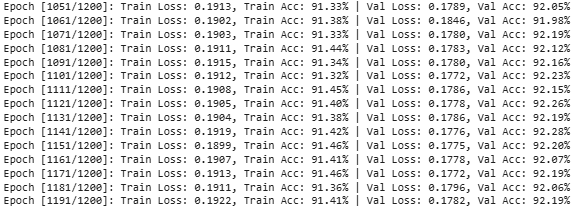

In [ ]:

def get_predictions(model, data_loader):
    model.eval()  # Set model to evaluation mode
    predictions = []
    actuals = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, targets in data_loader:
            inputs = inputs.float().to(device)
            targets = targets.to(device)

            # Forward pass to get outputs
            outputs = model(inputs)

            # Move outputs and targets to CPU and convert to numpy arrays
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(targets.cpu().numpy())

    # Convert lists to numpy arrays for easy handling
    predictions = np.array(predictions).squeeze()
    actuals = np.array(actuals).squeeze().astype(int)

    return predictions, actuals

In [ ]:
predictions, actuals = get_predictions(model_py, test_loader)

In [ ]:
predictions_binary = np.where(predictions > 0.5, 1, 0)

In [ ]:
print(classification_report(actuals, predictions_binary))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3444
           1       0.92      0.64      0.75      1056

    accuracy                           0.90      4500
   macro avg       0.91      0.81      0.85      4500
weighted avg       0.90      0.90      0.90      4500



# **6. Download the model**

In [ ]:
joblib.dump(best_model, f'{exps_dir}/model_ml.joblib')

['model_ml.joblib']